### Transfer Learning 

En esta Notebook profundizaremos en los conceptos de Transfer Learning y Fine-Tuning en el marco de las redes neuronales convolucionales.

Importamos las librerías necesarias y descargamos el dataset CIFAR-10 que nos brindará el conjunto de datos (imágenes) que vamos a usar para entrenar y testear nuestro modelo.

Tensorflow tiene el módulo `datasets` que nos ofrece varios datasets con los cuales practicar. 

Trasnfer Learning se utiliza en casos donde los datos de entrenamiento son escasos, pero se tiene modelos entrenados para tareas similares. 

Para ejemplificar, utilizaremos el dataset conocido como [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html).


| Propiedad | Valor |
| --- | --- |
| Clases | 10 |
| Tamaño de las imágenes | 32 X 32  |
| Canales de las imágenes | 3 (RGB)  |
| Instancias de entrenamiento | 50.000 |
| Instancias de testeo | 10.000 |
| Valor mínimo de cada pixel | 0 |
| Valor máximo de cada pixel | 255 |

El dataset contiene imágenes en color de 32 X 32 pixeles divididas en 10 clases:
1. Avión
1. Auto										
1. Pájaro									
1. Gato							
1. Venado										
1. Perro						
1. Rana									
1. Caballo										
1. Barco							
1. Camión


---


170498071/170498071 [==============================] - 8s 0us/step


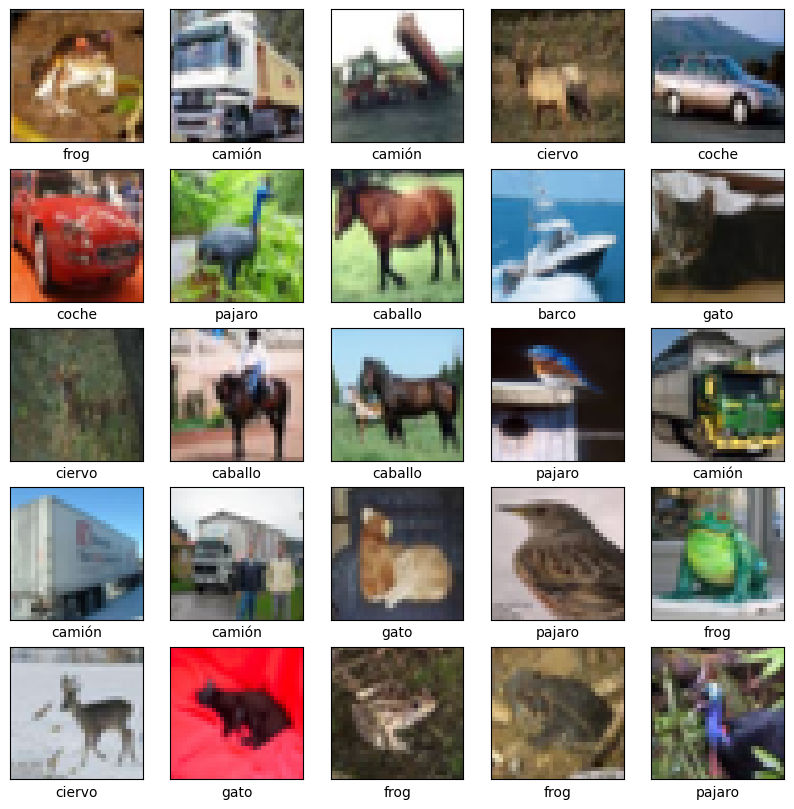

In [1]:
# Importamos las librerías
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, applications, optimizers
import matplotlib.pyplot as plt

#Cargamos los datos de entrenamiento y vemos las distintas clases que tenemos
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

class_names = ['avión', 'coche', 'pajaro', 'gato', 'ciervo',
               'dog', 'frog', 'caballo', 'barco', 'camión']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()


**Task: clasificación de imágenes.**

Nuestro problema consiste en clasificar las distintas imágenes que vayamos presentando a nuestra red neuronal, es decir, el modelo tendrá que predecir qué animal es. 

Para realizar esta tarea, utilizaremos una arquitectura de tipo `EfficientNet`. Esta red neuronal es muy famosa por ser capaz de distinguir distintas imágenes con un grado de acierto muy alto.

In [2]:
#Configuramos nuestra red neuronal
LR = 0.002
EPOCHS = 10
BATCH = 128
CLASES = 10

#4. Preprocesamos las imagenes
X_train = applications.efficientnet.preprocess_input(X_train)
X_test = applications.efficientnet.preprocess_input(X_test)

`NOTAS: `

La función **applications.efficientnet.preprocess_input()** es una función de preprocesamiento específica para el modelo EfficientNet. 

**EfficientNet** es una arquitectura de CNN que ha demostrado un rendimiento excepcional en tareas de clasificación de imágenes.

La función preprocess_input() se utiliza para realizar el preprocesamiento de las imágenes de entrada antes de pasarlas al modelo EfficientNet. Este preprocesamiento puede incluir normalización, cambio de escala y otras transformaciones necesarias para adaptar las imágenes al formato requerido por el modelo.

Es importante tener en cuenta que cada modelo puede tener su propia función de preprocesamiento específica. Por lo tanto, el uso de preprocess_input() puede variar dependiendo del modelo que estés utilizando. 

In [3]:
inputs = layers.Input(shape=(32,32,3))

#tenemos imagenes de dimensión 32x32x3, pero la red trabaja mejor con imágenes de dimensión 224x224x3
#implementamos una función que redimensione las imágenes del dataset.
upscale = layers.Lambda(lambda x: tf.image.resize_with_pad(x,224,224,method=tf.image.ResizeMethod.BILINEAR))(inputs)

`NOTAS`:

`upscale` es un tensor resultante de aplicar una transformación a inputs. En particular, se utiliza la función **tf.image.resize_with_pad()** de TensorFlow para redimensionar y rellenar las imágenes de entrada.

El código anterior se encarga de aplicar esta transformación. 

**layers.Lambda(lambda x: ...)**: crea una capa lambda en Keras que permite aplicar una función personalizada a los datos de entrada.

**tf.image.resize_with_pad()** es una función de TensorFlow que redimensiona una imagen de entrada manteniendo su relación de aspecto original y, si es necesario, realiza un relleno para ajustar la imagen a la forma deseada. En este caso, la función se utiliza para redimensionar las imágenes a una forma de (224, 224) y utiliza el método de interpolación bilineal para realizar el redimensionamiento.

In [4]:
#5. Cargamos la arquitectura ya entrenada de Efficientnet
modelo = applications.EfficientNetB0(include_top=False,  
                                     weights="imagenet",
                                     input_tensor = upscale, 
                                     input_shape=(224, 224, 3))

# si include_top=False ---> eliminamos el head de la red neuronal (nos quedan 239 capas)
# si include_top=True ---> cargamos toda la red (242 capas)

print(f"--> Número total de capas:{len(modelo.layers)}")
# modelo.summary()

16705208/16705208 [==============================] - 0s 0us/step
--> Número total de capas:239


`NOTAS`:

Creamos una instancia del modelo EfficientNetB0 utilizando la función **applications.EfficientNetB0()** de Keras. Veamos los argumentos utilizados en la creación del modelo:

`include_top=False`: indica que no se deben incluir las capas totalmente conectadas (top) en el modelo. Al establecerlo en False, se descartan las capas finales del modelo que están diseñadas para la clasificación de imágenes en un conjunto de clases específico. Esto es útil si deseas utilizar el modelo para transferir aprendizaje y agregar tus propias capas personalizadas al final.

`weights="imagenet"`: indica que se deben cargar los pesos pre-entrenados del modelo EfficientNetB0 entrenado en el conjunto de datos ImageNet. Estos pesos pre-entrenados se descargan automáticamente si no están disponibles localmente.

`input_tensor=upscale`: especifica el tensor de entrada del modelo. 

`input_shape=(224, 224, 3)`: define la forma del tensor de entrada. En este caso se espera que las imágenes de entrada tengan una forma de (224, 224, 3), lo que indica una resolución de 224x224 píxeles y 3 canales de color (RGB).

Una vez creado el modelo EfficientNetB0 se puede utilizar para realizar tareas como extracción de características o transferencia de aprendizaje en tus propios conjuntos de datos. 

Agregaremos las capas de clasificación o regresión en la parte superior del modelo para adaptarlo a nuestra tarea específica.

In [5]:
# freezamos todas las capas para que no se entrenen. 
# esta arquitectura cuenta con 239 capas (porque eliminamos las últimas)

for layer in modelo.layers: 
  layer.trainable = False

In [6]:
# añadiremos algunas capas que serán las únicas que entrenaremos
extractor_características = modelo.output

#añadimos dos capas
maxpool = layers.GlobalMaxPooling2D()(extractor_características)
ultima_capa = layers.Dense(CLASES, activation="softmax")(maxpool)

#creamos el modelo
modelo_tl = models.Model(inputs=inputs, outputs=ultima_capa)

#definimos el optimizador
opt = optimizers.Adam(learning_rate=LR)

#compilamos el modelo
modelo_tl.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])


No vamos a usar datos de validación, sólo de entrenamiento y testeo

In [7]:
# entrenamos el modelo y guardamos el history
history = modelo_tl.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH, validation_data=(X_test, y_test))

Epoch 1/10
391/391 [==============================] - 121s 262ms/step - loss: 0.8197 - sparse_categorical_accuracy: 0.7936 - val_loss: 0.5449 - val_sparse_categorical_accuracy: 0.8544
Epoch 2/10
391/391 [==============================] - 96s 245ms/step - loss: 0.4710 - sparse_categorical_accuracy: 0.8663 - val_loss: 0.4708 - val_sparse_categorical_accuracy: 0.8765
Epoch 3/10
391/391 [==============================] - 102s 260ms/step - loss: 0.4361 - sparse_categorical_accuracy: 0.8761 - val_loss: 0.5227 - val_sparse_categorical_accuracy: 0.8732
Epoch 4/10
391/391 [==============================] - 102s 260ms/step - loss: 0.3963 - sparse_categorical_accuracy: 0.8873 - val_loss: 0.4161 - val_sparse_categorical_accuracy: 0.8928
Epoch 5/10
391/391 [==============================] - 102s 260ms/step - loss: 0.3768 - sparse_categorical_accuracy: 0.8900 - val_loss: 0.3982 - val_sparse_categorical_accuracy: 0.8992
Epoch 6/10
391/391 [==============================] - 102s 260ms/step - loss: 0.4

**Resumen**: 

* Freezamos todas las capas (excepto el head, que no hemos cargado). Estas capas freezadas no serán entrenadas, simplemente actúan como un extractor de características. 

* Se usarán los pesos aprendidos (ajustados) cuando la red fue pre-entrenada con el dataset ImageNet.

* Añadimos 2 nuevas capas al final de todo (reemplazando el head original): una capa GlobalMaxPooling y una capa densa con 10 clases de salida (con “softmax” como función de activación).

GlobalMaxPooling2D de Keras: esta capa se utiliza comúnmente en CNN para realizar el proceso de "max pooling" global en la salida de la última capa convolucional. Calcula el valor máximo para cada canal en toda la imagen, lo que significa que toma el valor máximo de cada canal en la imagen completa y lo mantiene como resultado. Esto tiene el efecto de reducir la dimensionalidad del tensor de entrada a lo largo de las dimensiones espaciales, conservando solo la información más relevante y representativa.

La principal diferencia entre **GlobalMaxPooling2D** y **MaxPooling2D** radica en las dimensiones sobre las cuales se realiza la operación de "max pooling".

*MaxPooling2D* se aplica en ventanas locales dentro de la imagen de entrada y realiza una reducción espacial, es decir, reduce las dimensiones espaciales (alto y ancho) de la imagen, manteniendo los canales intactos. Por lo general, se utiliza para extraer características locales y reducir la resolución espacial de la salida de las capas convolucionales anteriores.

*GlobalMaxPooling2D* realiza una reducción global, considerando la imagen completa en lugar de ventanas locales. En lugar de aplicar la operación de "max pooling" a regiones locales, GlobalMaxPooling2D selecciona el valor máximo a lo largo de todas las dimensiones espaciales para cada canal. Esto reduce aún más la dimensionalidad espacial a un solo valor por canal, conservando solo la característica más relevante en cada canal.

MaxPooling2D es comúnmente utilizado dentro de la arquitectura de la red convolucional, mientras que GlobalMaxPooling2D se utiliza a menudo en la parte final de la red para capturar características globales antes de la capa de salida.

* Obserbamos que con tan solo 3 epcohs hemos conseguido una accuracy > 85%,  lo cual no está nada mal teniendo en cuenta la pobre calidad de las imágenes.

***
### Fine-Tuning

Se diferencia del Transfer Learning en que se descongela parte del modelo (o incluso el modelo entero). 

En vez de freezar todos los pesos del modelo original, descongelamos por ejemplo las últimas 38 capas, de tal forma que en vez de entrenar 2 capas como hicimos anteriormente, entrenaremos 40.

El código a usar es exactamente el mismo que para hacer Transfer Learning, sólo se tiene que  definir cuales capas serán entrenables y cuales seguirán freezadas.

In [8]:
#cargamos la arquitectura ya entrenada de Efficientnet (sin el head)
ft_efn_model = applications.EfficientNetB0(include_top=False, weights="imagenet", input_tensor = upscale, input_shape=(240, 240, 3))

#entrenamos las últimas 38 capas y freezamos el resto
for layer in ft_efn_model.layers[:-38]:
  layer.trainable = False
  
extractor_características = ft_efn_model.output

#añadimos dos capas nuevas
maxpool = layers.GlobalMaxPooling2D()(extractor_características)
ultima_capa = layers.Dense(CLASES, activation="softmax")(maxpool)

modelo_ft = models.Model(inputs=inputs, outputs=ultima_capa)

opt = optimizers.Adam(learning_rate=LR)
modelo_ft.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["sparse_categorical_accuracy"])
# modelo_ft.summary()

EPOCHS = 3

#entrenamos
history = modelo_ft.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH, validation_data=(X_test, y_test))

Epoch 1/3
391/391 [==============================] - 132s 303ms/step - loss: 0.4330 - sparse_categorical_accuracy: 0.8774 - val_loss: 0.2182 - val_sparse_categorical_accuracy: 0.9301
Epoch 2/3
391/391 [==============================] - 118s 301ms/step - loss: 0.1984 - sparse_categorical_accuracy: 0.9330 - val_loss: 0.2188 - val_sparse_categorical_accuracy: 0.9313
Epoch 3/3
391/391 [==============================] - 113s 288ms/step - loss: 0.1450 - sparse_categorical_accuracy: 0.9500 - val_loss: 0.2014 - val_sparse_categorical_accuracy: 0.9395


**Resumen:**

* Hemos cambiado la parte que congela las capas, quedando las últimas 38 capas 
descongeladas para que sean entrenadas y los pesos puedan variar.

* Observamos que en 3 epochs y con poco código hemos logrado aprox 90% de acierto ¡Impresionante!

***
**Conclusiones**

* Cuando entrenamos una red neuronal, ella debe aprender un conjunto de pesos que se inicializan aleatoriamente. Al hacer Transfer Learning ya tenemos estos pesos ajustados, por lo que solo necesitamos adaptar unas pocas capas al final de la red para adaptarla al nuevo problema.

* Hemos escogido la arquitectura neuronal EfficienNet que ha sido entrenada previamente con el dataset ImageNet. Este conjunto de datos tiene las clases que nosotros necesitamos en nuestro problema (ranas, aviones, camiones, etc.), por lo que podemos reutilizar la red neuronal y sus pesos para nuestro dataset.

* ImageNet es una base de datos famosa, con millones de imágenes y miles de clases distintas, que se utiliza para probar las redes neuronales y descubrir cuáles son mejores.

**¿Cuándo usar Transfer Learning y cuándo usar Fine Tuning?**

* Depende de nuestro conjunto de datos, si el dataset es muy parecido a los datos originales con los que se entrenó la red que vamos a escoger, entonces usaremos Transfer Learning. 

* Si hay diferencia entre los conjuntos de datos, entonces usaremos Fine Tuning, y cuanto más diferencia haya, más capas debemos descongelar.